In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import ast
from collections import defaultdict
import os
import sys
import json
import textwrap
import importlib
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *

In [2]:
# Usage
BASE_DIR = "../experiment11[time-depol-trotter-vs-standard]/data"
RAW_SIM_DATA = load_simulation_tree(BASE_DIR)
EXACT_SOL :float = -7.29622981055876

In [3]:
RAW_SIM_DATA.keys()

dict_keys(['time-depol-trotter', 'time-depol', 'time-depol-trotter_delt0.03'])

In [4]:
RAW_SIM_DATA["time-depol-trotter"].keys()

dict_keys(['ZNE', 'VQE', 'VQE_noiseoff'])

In [5]:
import numpy as np

def process_simulation_data(raw: dict) -> dict:
    processed = {}

    # Iterate over "time-depol", "time-depol-trotter", etc.
    # We look inside the "data" folder directly if it exists
    experiments = raw.get("data", raw)

    for category_key, category_contents in sorted(experiments.items()):
        
        # Dictionary to hold results for this specific experiment category
        category_entry = {
            "VQE": {"mean": 0.0, "std": 0.0},
            "VQE_noiseoff": {"mean": 0.0, "std": 0.0},
            "ZNE": {}
        }

        for folder_name, folder_contents in category_contents.items():
            
            # --- 1. Handle ZNE (ric2, ric4, etc.) ---
            if folder_name == "ZNE":
                for label, runs in sorted(folder_contents.items()):
                    ext_vals, noises, exp_vals = [], [], []
                    tmax = None

                    for run_key, run in runs.items():
                        if run is None or "REDUNDANT" in run_key: continue
                        try:
                            tmax = run["config"]["ansatz"]["ugate"]["time"]["max"]
                            output = run["output"]["zne_values"]
                            ext_vals.append(output["extrapolated_value"])
                            noises.append(output["others"]["sorted_noise"])
                            exp_vals.append(output["others"]["sorted_expectation_vals"])
                        except (KeyError, TypeError): continue

                    if ext_vals:
                        category_entry["ZNE"][label] = {
                            "tmax": tmax,
                            "mean": float(np.mean(ext_vals)),
                            "std": float(np.std(ext_vals)),
                            "sorted_noise": noises,
                            "sorted_expvals": exp_vals,
                        }

            # --- 2. Handle VQE and VQE_noiseoff separately ---
            elif folder_name in ["VQE", "VQE_noiseoff"]:
                costs = []
                # Iterate through the runs in the VQE or VQE_noiseoff folder
                for run_key, run in folder_contents.items():
                    if run is not None and "REDUNDANT" not in run_key:
                        try:
                            costs.append(run["output"]["optimized_minimum_cost"][0])
                        except (KeyError, IndexError, TypeError): continue
                
                if costs:
                    category_entry[folder_name] = {
                        "mean": float(np.mean(costs)),
                        "std": float(np.std(costs))
                    }

        processed[category_key] = category_entry

    return processed

In [6]:
PROCESSED_SIM_DATA = process_simulation_data(RAW_SIM_DATA)

for tmax, entry in sorted(PROCESSED_SIM_DATA.items()):
    print(f"\n{tmax}")
    if "VQE" in entry:
        v = entry["VQE"]
        print(f"  VQE        → mean={v['mean']:.6f}  std={v['std']:.6f}")
    if "ZNE" in entry:
        for label, z in entry["ZNE"].items():
            print(f"  ZNE/{label:6s} → mean={z['mean']:.6f}  std={z['std']:.6f}  n={len(z['sorted_noise'])} runs")


time-depol
  VQE        → mean=-5.376872  std=0.151060
  ZNE/mul-var3-d1 → mean=-6.361198  std=0.130655  n=0 runs
  ZNE/mul-var3-d2 → mean=-7.470264  std=0.105026  n=0 runs
  ZNE/mul-var3-d3 → mean=-71.965104  std=8.332641  n=0 runs
  ZNE/mul1   → mean=-6.175960  std=0.143181  n=0 runs
  ZNE/ric2   → mean=-6.437801  std=0.124230  n=10 runs
  ZNE/ric4   → mean=-6.983444  std=0.072552  n=10 runs

time-depol-trotter
  VQE        → mean=-5.218940  std=0.131820
  ZNE/mul1   → mean=-6.025411  std=0.128558  n=0 runs
  ZNE/ric2   → mean=-6.305544  std=0.112520  n=10 runs
  ZNE/ric4   → mean=-6.901067  std=0.068562  n=10 runs

time-depol-trotter_delt0.03
  VQE        → mean=-5.211605  std=0.103071
  ZNE/ric4   → mean=-6.893149  std=0.056367  n=10 runs


In [7]:
PROCESSED_SIM_DATA.keys()

dict_keys(['time-depol', 'time-depol-trotter', 'time-depol-trotter_delt0.03'])

In [8]:
# 1. Access the noiseoff folder from RAW_SIM_DATA
noiseoff_folder = RAW_SIM_DATA["time-depol-trotter"].get("VQE_noiseoff", {})

# 2. Extract values from all valid runs
noiseoff_values = []
for run_key, run in noiseoff_folder.items():
    if run is not None and "REDUNDANT" not in run_key:
        try:
            # Extract the first element of the optimized cost list
            cost = run["output"]["optimized_minimum_cost"][0]
            noiseoff_values.append(cost)
        except (KeyError, IndexError, TypeError):
            continue

# 3. Compute Stats
if noiseoff_values:
    noiseoff_mean = float(np.mean(noiseoff_values))
    noiseoff_std  = float(np.std(noiseoff_values))
else:
    noiseoff_mean, noiseoff_std = 0.0, 0.0

print(f"Noise-free Mean: {noiseoff_mean:.6f}")
print(f"Noise-free Std:  {noiseoff_std:.6f}")

Noise-free Mean: -7.284018
Noise-free Std:  0.012635


In [9]:
import numpy as np
import warnings

def process_for_master_plotting(raw_data: dict) -> dict:
    processed = {}
    # Access the 'data' folder from your experiment tree
    experiments = raw_data.get("data", raw_data)

    for exp_name, content in experiments.items():
        processed[exp_name] = {}
        
        # --- 1. Aggregating VQE_noiseoff (The Star Marker) ---
        nf_folder = content.get("VQE_noiseoff", {})
        nf_costs = []
        for k, run in nf_folder.items():
            if run and "REDUNDANT" not in k and "output" in run:
                try:
                    nf_costs.append(run["output"]["optimized_minimum_cost"][0])
                except (KeyError, IndexError, TypeError):
                    continue
        
        nf_stats = {
            "mean": float(np.mean(nf_costs)) if nf_costs else None,
            "std":  float(np.std(nf_costs)) if nf_costs else None
        }

        # --- 2. Processing ZNE Subfolders (mul1, ric2, etc.) ---
        zne_folder = content.get("ZNE", {})
        
        # If mul1 is missing, ensure the key exists in the raw zne_folder
        for label, runs in zne_folder.items():
            ext_vals, all_y_curves = [], []
            noise_levels = None
            
            for k, run in runs.items():
                # Skip nulls or redundant files
                if not run or "REDUNDANT" in k or "output" not in run: 
                    continue
                
                # Safely navigate the nested structure
                zne_vals = run["output"].get("zne_values", {})
                others = zne_vals.get("others", {})
                
                # Fallback logic: check 'others' first, then 'zne_values' directly
                current_y = others.get("sorted_expectation_vals") or zne_vals.get("sorted_expectation_vals")
                current_n = others.get("sorted_noise") or zne_vals.get("sorted_noise")
                ext_val = zne_vals.get("extrapolated_value")

                if current_y and current_n and ext_val is not None:
                    ext_vals.append(ext_val)
                    all_y_curves.append(current_y)
                    if noise_levels is None:
                        noise_levels = current_n
                else:
                    # Debug print to see which file is failing the check
                    print(f"⚠️ Skipping {exp_name}/{label}/{k}: Missing required keys.")

            # --- 3. Final Formatting for master.py ---
            if ext_vals and all_y_curves:
                y_array = np.array(all_y_curves)
                processed[exp_name][label] = {
                    "noise_type":     "depolarizing", 
                    "exact_sol":      EXACT_SOL, # Global variable you defined
                    "sorted_noise":   noise_levels,
                    "mean_exp_vals":  np.mean(y_array, axis=0).tolist(),
                    "std_exp_vals":   np.std(y_array, axis=0).tolist(),
                    "zne_mean":       float(np.mean(ext_vals)),
                    "zne_std":        float(np.std(ext_vals)),
                    "mean_noise_off": nf_stats["mean"],
                    "std_noise_off":  nf_stats["std"]
                }
            else:
                print(f"❌ Failed to process ZNE label: {label} (No valid runs found)")

    return processed

In [10]:
results = process_for_master_plotting(RAW_SIM_DATA)

⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#3_20260325_152928_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#6_20260325_153120_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#1_20260325_152806_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#7_20260325_153155_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#10_20260325_153342_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#9_20260325_153307_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_tro

In [11]:
figsize = (8, 5)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in './reports' folder): comparison_ric2_ric4.eps


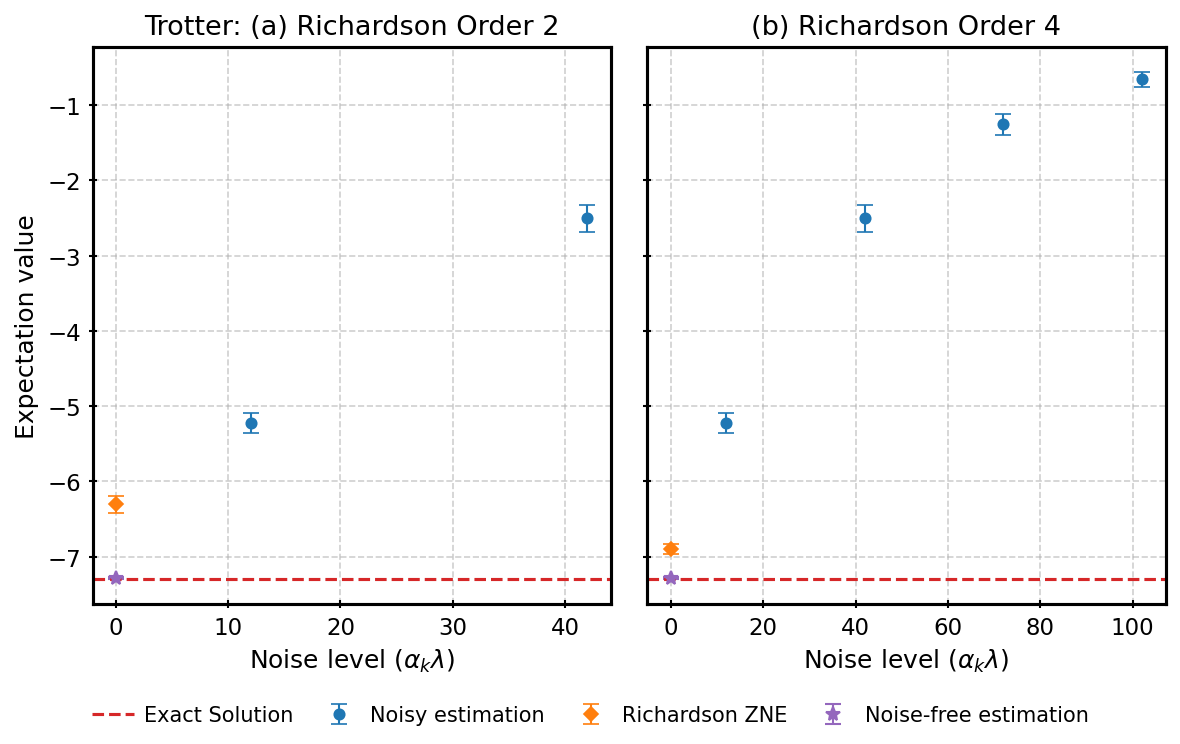

In [12]:
# 1. Get the processed data

exp_data = results["time-depol-trotter"]

# 2. Prepare the list for subplots
data_to_plot = [exp_data["ric2"], exp_data["ric4"]]

# 3. Use the master.py function
COLORS = {
    "noisy": "#1f77b4", "zne": "#ff7f0e", 
    "exact": "#d62728", "noise_free": "#9467bd"
}

plot_multi_zne(
    data_list=data_to_plot,
    plot_colors=COLORS,
    plot_titles=["Trotter: (a) Richardson Order 2", "(b) Richardson Order 4"],
    ncols=2,
    figsize=figsize,
    output_dir="./reports",
    plot_file_name="comparison_ric2_ric4",
    global_legend=True,
    show_plot = False,
    
)

⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#3_20260325_152928_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#6_20260325_153120_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#1_20260325_152806_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#7_20260325_153155_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#10_20260325_153342_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_trotter_tmax20_ricmul_sample#9_20260325_153307_ZNE: Missing required keys.
⚠️ Skipping time-depol-trotter/mul1/AUTOMATE_xy-iss_noisy_time_evo_time_depol_tro

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in './reports' folder): comparison_ric2_ric4.eps


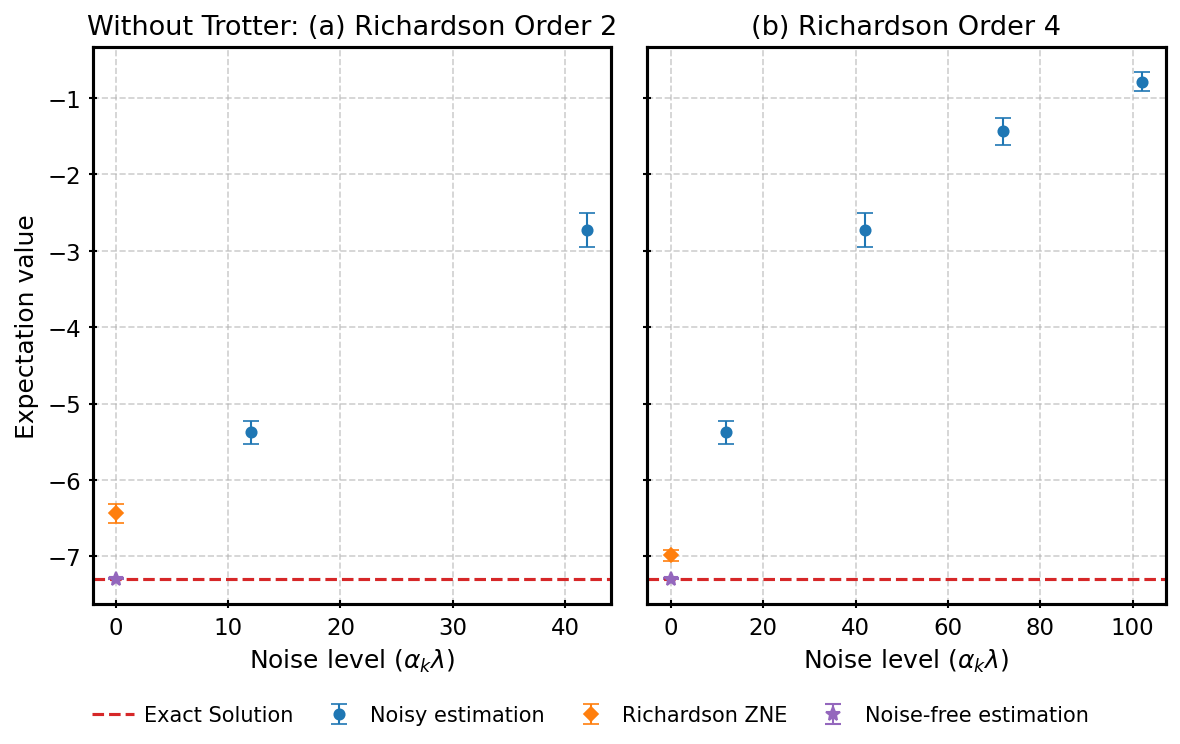

In [13]:
# 1. Get the processed data
results = process_for_master_plotting(RAW_SIM_DATA)
exp_data = results["time-depol"]

# 2. Prepare the list for subplots
data_to_plot = [exp_data["ric2"], exp_data["ric4"]]

# 3. Use the master.py function
COLORS = {
    "noisy": "#1f77b4", "zne": "#ff7f0e", 
    "exact": "#d62728", "noise_free": "#9467bd"
}

plot_multi_zne(
    data_list=data_to_plot,
    plot_colors=COLORS,
    plot_titles=["Without Trotter: (a) Richardson Order 2", "(b) Richardson Order 4"],
    ncols=2,
    figsize=figsize,
    output_dir="./reports",
    plot_file_name="comparison_ric2_ric4",
    global_legend=True,
    show_plot = False
)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


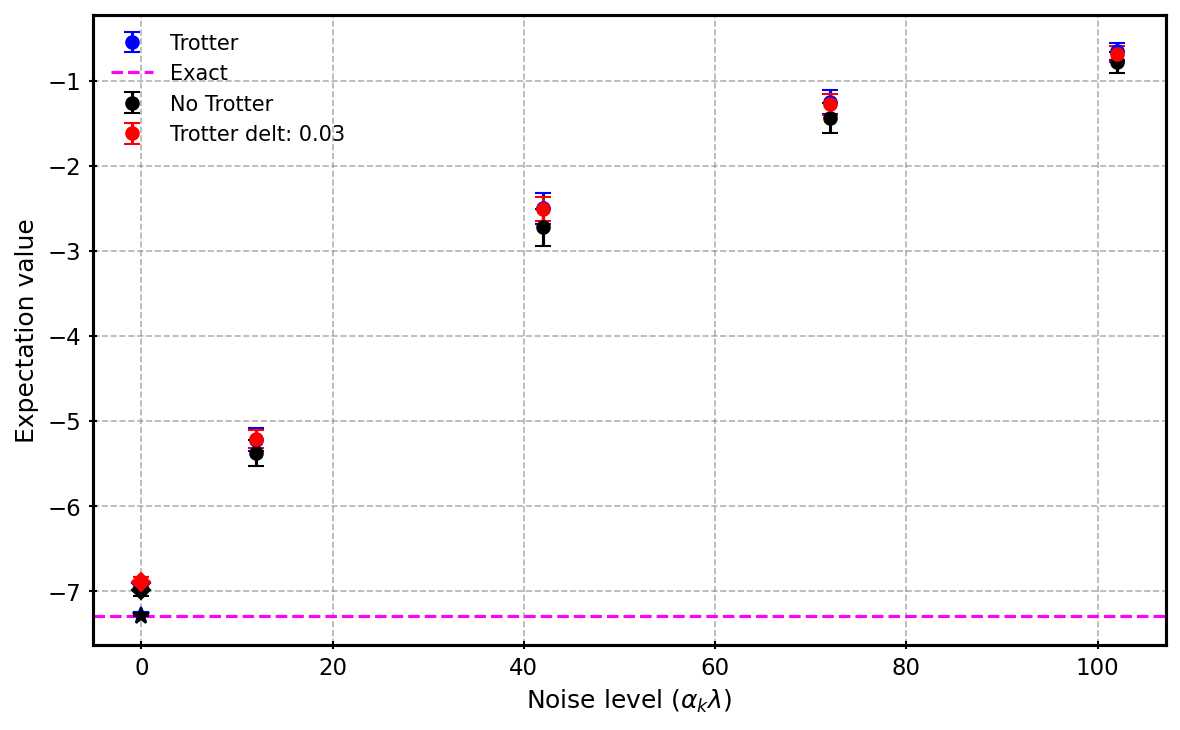

In [14]:
# 1. Get the processed data

data_trotter = results["time-depol-trotter"]
data_no_trotter = results["time-depol"]
data_trotter_delt0_03 = results["time-depol-trotter_delt0.03"]

# 2. Prepare the list for subplots
data_to_plot = [data_trotter["ric4"], data_no_trotter["ric4"], data_trotter_delt0_03["ric4"]]

# 3. Use the master.py function
COLORS =  [
    "#0000ff", 
    "black",
    "#ff0000" 
]
plot_titles=[
    "Trotter",
    "No Trotter",
    "Trotter delt: 0.03"
]
plot_single_zne_imposed(
    data_list=data_to_plot,
    plot_colors={"exact": "magenta"},
    #plot_colors=COLORS,
    plot_titles=plot_titles,
     dataset_colors=COLORS,
    figsize=figsize,
    output_dir="./reports",
    plot_file_name="comparison_ric2_ric4",
    #global_legend=True,
    show_plot = False,
    
)

In [15]:
data_to_plot[0].keys()

dict_keys(['noise_type', 'exact_sol', 'sorted_noise', 'mean_exp_vals', 'std_exp_vals', 'zne_mean', 'zne_std', 'mean_noise_off', 'std_noise_off'])

---

### Multivariate

In [16]:
def process_single_mul(runs_dict):
    """
    Processes a specific multiplier's runs. 
    Handles variable noise vector lengths (3D or 4D).
    """
    extrap_vals = []
    dp_costs = defaultdict(list)
    exact_sol = None

    for run_key, sample in runs_dict.items():
        if sample is None or "REDUNDANT" in run_key:
            continue

        out = sample.get("output", {})
        zne_vals = out.get("zne_values", {})

        if exact_sol is None:
            exact_sol = out.get("exact_sol")

        if "extrapolated_value" in zne_vals:
            extrap_vals.append(float(zne_vals["extrapolated_value"]))

        for pt in zne_vals.get("sampled data", []):
            # Coordinates are everything BUT the last element
            coord_tuple = tuple(map(int, pt[:-1])) 
            # The last element is the cost
            cost_val = float(pt[-1])
            
            key = str(coord_tuple)
            dp_costs[key].append(cost_val)

    return {
        "mul_data": {
            "extrapolated": {
                "mean": float(np.mean(extrap_vals)) if extrap_vals else 0,
                "std":  float(np.std(extrap_vals)) if extrap_vals else 0,
            },
            "data_points": {
                key: {
                    "mean": float(np.mean(vals)),
                    "std":  float(np.std(vals)),
                }
                for key, vals in sorted(dp_costs.items())
            },
        },
        "exact_sol": exact_sol
    }

def plot_ricmul(processed, title = None, save_path=None):
    exact = processed.get("exact_sol")
    label = "mul_data"
    
    data_points = processed[label]["data_points"]
    extrapolated = processed[label]["extrapolated"]

    # 1. Sort raw data keys by noise level (sum of vector)
    sorted_keys = sorted(data_points.keys(), key=lambda k: sum(ast.literal_eval(k)))

    # 2. Build X-axis: ZNE first, then Noisy Points
    # Create a 'Zero' label based on the length of the first data point vector
    first_key_len = len(ast.literal_eval(sorted_keys[0]))
    zne_label = f"ZNE\n({','.join(['0']*first_key_len)})"
    
    x_labels = [zne_label] + sorted_keys
    x = np.arange(len(x_labels))

    # 3. Build Y-axis data: Prepend Extrapolated to the start
    means = [extrapolated["mean"]] + [data_points[k]["mean"] for k in sorted_keys]
    stds = [extrapolated["std"]] + [data_points[k]["std"] for k in sorted_keys]
    
    means = np.array(means)
    stds = np.array(stds)

    fig, ax = plt.subplots(figsize=(10, 5))

    # Plot lines and shaded error bars
    ax.plot(x, means, marker="o", color="#60a5fa", linewidth=2,
        label=f"Simulation Data (ZNE: {extrapolated['mean']:.4f} ± {extrapolated['std']:.4f})",
        zorder=3)
    #ax.plot(x, means, marker="o", color="#60a5fa", linewidth=2, label="Simulation Data", zorder=3)
    ax.fill_between(x, means - stds, means + stds, color="#60a5fa", alpha=0.2, zorder=2)

    # Exact Solution Reference
    if exact is not None:
        ax.axhline(exact, color="crimson", linestyle="--", linewidth=1.5, 
                   label=f"Exact: {exact:.4f}", zorder=4)

    # Vertical line to separate ZNE from the measured noisy data
    ax.axvline(0.5, color="#666", linestyle=":", alpha=0.8)

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_title(title, fontsize=12, pad=15)
    ax.set_ylabel("Cost (Expectation Value)")
    ax.set_xlabel("Noise Vector (nR+nY, nCz, nU)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.close(fig)
    return fig

{'mul_data': {'extrapolated': {'mean': -6.3611980348751755, 'std': 0.1306551010033744}, 'data_points': {'(18, 6, 18)': {'mean': -2.7245503599665066, 'std': 0.21873561728296625}, '(30, 2, 18)': {'mean': -2.9249747410161446, 'std': 0.19764160448589457}, '(38, 6, 42)': {'mean': -1.4669941648812403, 'std': 0.1672874741205647}, '(4, 2, 6)': {'mean': -5.376872043907548, 'std': 0.15106007040720068}}}, 'exact_sol': -7.296229810558759}


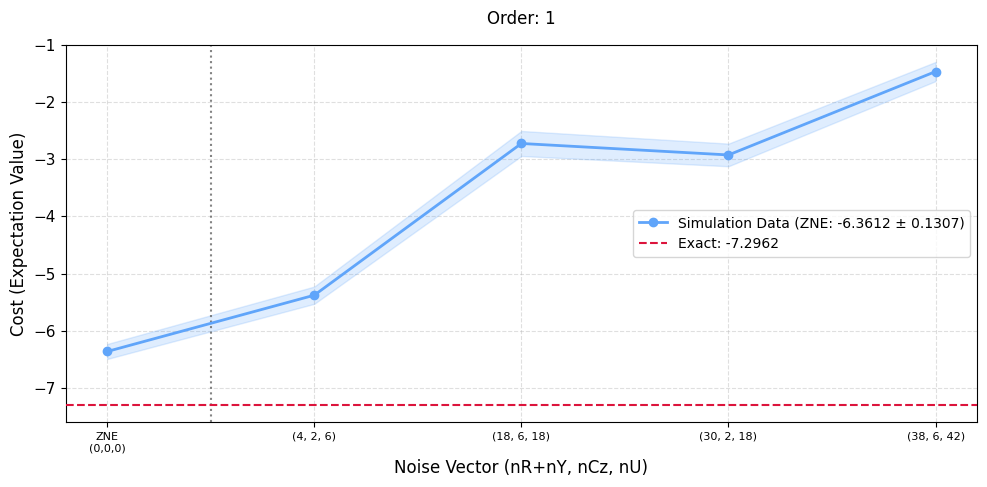

In [17]:
# Multivariate (3 noise variable vs extrapolated value) Richardson extrapolation of order 1 
ricmul_d1 = process_single_mul(RAW_SIM_DATA["time-depol"]["ZNE"]["mul-var3-d1"])
print(ricmul_d1)
plot_ricmul(ricmul_d1, title = "Order: 1")

{'mul_data': {'extrapolated': {'mean': -7.470263848049479, 'std': 0.10502571710577996}, 'data_points': {'(12, 6, 6)': {'mean': -3.5380684632620003, 'std': 0.23789846995370637}, '(18, 6, 18)': {'mean': -2.724550359966506, 'std': 0.21873561728296612}, '(20, 2, 6)': {'mean': -4.221612279609098, 'std': 0.21387258765364386}, '(22, 2, 18)': {'mean': -3.2937091735752517, 'std': 0.18925723292863697}, '(30, 2, 18)': {'mean': -2.9249747410161446, 'std': 0.19764160448589466}, '(34, 6, 18)': {'mean': -1.9788056071238327, 'std': 0.18779038246255927}, '(38, 6, 42)': {'mean': -1.4669941648812401, 'std': 0.16728747412056463}, '(4, 10, 6)': {'mean': -2.9794087615255243, 'std': 0.2471698055373182}, '(4, 2, 6)': {'mean': -5.376872043907548, 'std': 0.15106007040720087}, '(4, 6, 6)': {'mean': -3.9755209200225545, 'std': 0.2254045672681257}}}, 'exact_sol': -7.296229810558759}


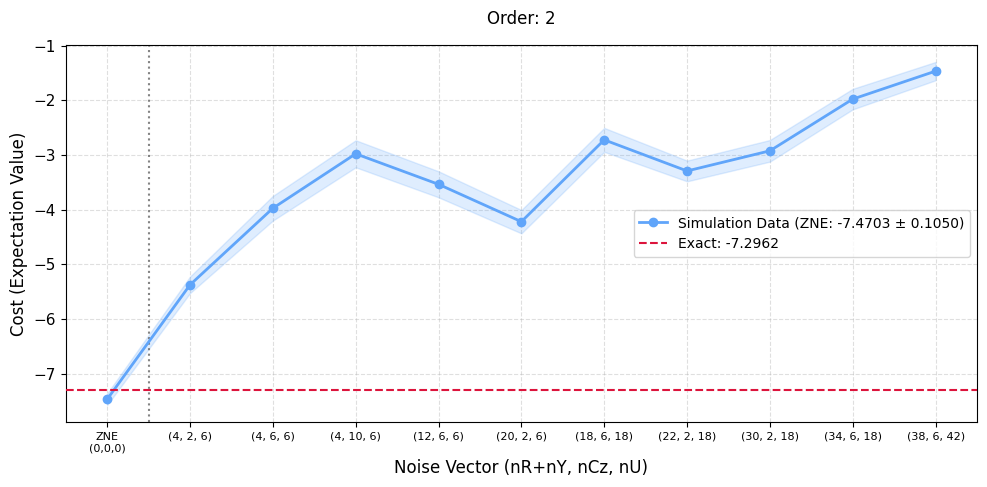

In [18]:
# Multivariate (3 noise variable vs extrapolated value) Richardson extrapolation of order 1 
ricmul_d2 = process_single_mul(RAW_SIM_DATA["time-depol"]["ZNE"]["mul-var3-d2"])
print(ricmul_d2)
plot_ricmul(ricmul_d2, title = "Order: 2")

{'mul_data': {'extrapolated': {'mean': -71.9651039507672, 'std': 8.33264115628131}, 'data_points': {'(12, 10, 6)': {'mean': -2.6654851488230014, 'std': 0.24691473368733313}, '(12, 6, 6)': {'mean': -3.5380684632619994, 'std': 0.23789846995370648}, '(120, 2, 30)': {'mean': -0.5396501490757531, 'std': 0.08489630241879506}, '(136, 6, 30)': {'mean': -0.3135009639349734, 'std': 0.057429589680468476}, '(168, 6, 30)': {'mean': -0.19493260995303552, 'std': 0.039544570489535344}, '(18, 6, 18)': {'mean': -2.724550359966506, 'std': 0.2187356172829664}, '(20, 2, 6)': {'mean': -4.221612279609099, 'std': 0.21387258765364398}, '(20, 6, 6)': {'mean': -3.1555330670643804, 'std': 0.2443533017963666}, '(22, 2, 18)': {'mean': -3.2937091735752517, 'std': 0.18925723292863705}, '(28, 2, 6)': {'mean': -3.7532050006186095, 'std': 0.23048933172650243}, '(30, 2, 18)': {'mean': -2.924974741016145, 'std': 0.19764160448589452}, '(34, 6, 18)': {'mean': -1.9788056071238327, 'std': 0.18779038246255922}, '(38, 6, 42)': 

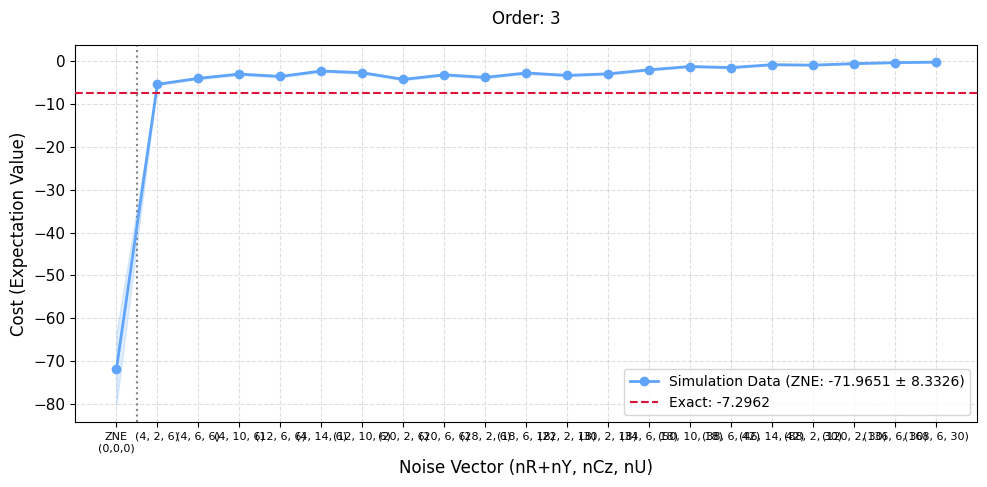

In [19]:
# Multivariate (3 noise variable vs extrapolated value) Richardson extrapolation of order 1 
ricmul_d2 = process_single_mul(RAW_SIM_DATA["time-depol"]["ZNE"]["mul-var3-d3"])
print(ricmul_d2)
plot_ricmul(ricmul_d2, title = "Order: 3")

In [2]:
"""
Scikit-learn multivariate polynomial extrapolation for Zero-Noise Extrapolation (ZNE).

Key insight
-----------
The input columns are raw gate counts  (base_gates × λ), NOT dimensionless scale
factors λ.  The polynomial is fitted in gate-count space and evaluated at
(0, 0, 0), which is mathematically equivalent to evaluating at λ = (0, 0, 0)
in scale-factor space — because zero gate count ↔ zero noise level.

Why degree 3 is unreliable here
--------------------------------
With 3 independent variables and degree 3 the polynomial has exactly C(3+3,3) = 20
monomial terms.  Given 20 data points the system is exactly determined — the
polynomial passes through every point perfectly (R² = 1.0) but is wildly
overfitted, producing the same catastrophic extrapolation (-68.5) as the
Cramer's-rule Richardson method.

Degree 2 (10 terms, 20 points) is overdetermined → least-squares fit →
far more stable extrapolation and still achieves R² ≈ 0.997.
"""

import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score


# ---------------------------------------------------------------------------
# Data
# ---------------------------------------------------------------------------
DATA = np.array([
        [0.4, 2, 6, -5.456395640996902],
        [1.8, 6, 18, -2.843680194399024],
        [3.0, 2, 18, -3.0472553887725624],
        [3.8000000000000003, 6, 42, -1.5636117319495977],
        [0.4, 6, 6, -4.091609472844327],
        [2.2, 2, 18, -3.4123205398941696],
        [2.0, 2, 6, -4.33532162407993],
        [0.4, 10, 6, -3.09980062928075],
        [1.2000000000000002, 6, 6, -3.6590702053185638],
        [3.4000000000000004, 6, 18, -2.095408189501491],
        [2.8000000000000003, 2, 6, -3.873861764578921],
        [0.4, 14, 6, -2.371369500436839],
        [8.8, 2, 30, -0.9765390431899519],
        [1.2000000000000002, 10, 6, -2.782938048899565],
        [2.0, 6, 6, -3.277430382137392],
        [12.0, 2, 30, -0.5994528714954206],
        [13.600000000000001, 6, 30, -0.3543521007734822],
        [5.0, 10, 18, -1.3008344299984786],
        [16.8, 6, 30, -0.2234804563856681],
        [4.6000000000000005, 14, 42, -0.8458036461891286]
      ])

EXACT_SOLUTION = -7.296229810558759


# ---------------------------------------------------------------------------
# Extrapolation
# ---------------------------------------------------------------------------
def sklearn_multivariate_zne(
    data: np.ndarray,
    degree: int = 2,
) -> dict:
    """
    Fit a multivariate polynomial to (noise_vars..., expectation_value) data
    using scikit-learn and extrapolate to the zero-noise limit f(0, 0, ..., 0).

    Parameters
    ----------
    data    : 2-D array of shape (N, n_vars + 1).
              First n_vars columns are noise variables; last column is E[O].
    degree  : Polynomial degree.  Degree 2 is recommended when the number of
              data points equals C(n_vars + degree, degree) for degree 3,
              because degree 3 would be exactly determined and overfit.

    Returns
    -------
    dict with keys:
        extrapolated_value  – f(0, 0, ..., 0)
        r2_score            – goodness of fit on training data
        n_terms             – number of polynomial basis terms used
        n_data_points       – number of data points used
        degree              – polynomial degree used
        model               – fitted sklearn Pipeline
    """
    n_vars = data.shape[1] - 1
    X = data[:, :n_vars]
    y = data[:, n_vars]

    # Number of monomials for the chosen degree
    from math import comb
    n_terms = comb(n_vars + degree, degree)

    if n_terms > len(data):
        raise ValueError(
            f"Under-determined system: degree {degree} needs {n_terms} terms "
            f"but only {len(data)} data points supplied. "
            f"Reduce the degree or supply more data."
        )
    if n_terms == len(data):
        import warnings
        warnings.warn(
            f"Exactly-determined system (degree={degree}, {n_terms} terms = "
            f"{len(data)} points): polynomial interpolates every point exactly "
            f"and will likely overfit. Consider a lower degree.",
            stacklevel=2,
        )

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=True)),
        ("reg",  LinearRegression(fit_intercept=False)),
    ])
    model.fit(X, y)

    zero_point = np.zeros((1, n_vars))
    extrapolated = float(model.predict(zero_point)[0])
    r2 = float(model.score(X, y))

    return {
        "extrapolated_value": extrapolated,
        "r2_score":           r2,
        "n_terms":            n_terms,
        "n_data_points":      len(data),
        "degree":             degree,
        "model":              model,
    }


# ---------------------------------------------------------------------------
# Demo
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    X_raw = DATA[:, :3]
    y_raw = DATA[:,  3]

    print("=" * 60)
    print("Scikit-learn multivariate ZNE extrapolation")
    print("=" * 60)
    print(f"Data shape : {DATA.shape}  ({DATA.shape[0]} points, {DATA.shape[1]-1} noise vars)")
    print(f"Exact value: {EXACT_SOLUTION}")
    print()

    # ── Degree comparison ────────────────────────────────────────────────
    print(f"{'Degree':<8} {'# terms':<10} {'System':<18} {'Extrapolated':>14} {'R²':>10} {'Error':>10}")
    print("-" * 64)

    from math import comb
    for deg in [1, 2, 3]:
        n_terms = comb(3 + deg, deg)
        if n_terms > len(DATA):
            system = "under-determined"
        elif n_terms == len(DATA):
            system = "exact-fit (bad!)"
        else:
            system = "over-determined ✓"

        try:
            result = sklearn_multivariate_zne(DATA, degree=deg)
            val   = result["extrapolated_value"]
            r2    = result["r2_score"]
            error = abs(val - EXACT_SOLUTION)
            print(f"{deg:<8} {n_terms:<10} {system:<18} {val:>14.6f} {r2:>10.6f} {error:>10.6f}")
        except Exception as e:
            print(f"{deg:<8} {n_terms:<10} {system:<18} {'ERROR: '+str(e):>36}")

    # ── Best result ──────────────────────────────────────────────────────
    print()
    best = sklearn_multivariate_zne(DATA, degree=2)
    print(f"Recommended (degree=2):")
    print(f"  Extrapolated value : {best['extrapolated_value']:.6f}")
    print(f"  Exact solution     : {EXACT_SOLUTION}")
    print(f"  Absolute error     : {abs(best['extrapolated_value'] - EXACT_SOLUTION):.6f}")
    print(f"  R²                 : {best['r2_score']:.6f}")
    print(f"  Polynomial terms   : {best['n_terms']} (overdetermined: {best['n_data_points']} pts)")
    print()

    # ── Fitted coefficients ──────────────────────────────────────────────
    print()
    print("Degree-2 fitted polynomial coefficients:")
    poly  = best["model"].named_steps["poly"]
    reg   = best["model"].named_steps["reg"]
    names = poly.get_feature_names_out(["nG1", "nG2", "nG3"])
    for name, coef in zip(names, reg.coef_):
        print(f"  {name:<18} {coef:+.6f}")

Scikit-learn multivariate ZNE extrapolation
Data shape : (20, 4)  (20 points, 3 noise vars)
Exact value: -7.296229810558759

Degree   # terms    System               Extrapolated         R²      Error
----------------------------------------------------------------
1        4          over-determined ✓       -4.961176   0.907636   2.335054
2        10         over-determined ✓       -6.743529   0.996569   0.552701
3        20         exact-fit (bad!)       -68.501098   1.000000  61.204868

Recommended (degree=2):
  Extrapolated value : -6.743529
  Exact solution     : -7.296229810558759
  Absolute error     : 0.552701
  R²                 : 0.996569
  Polynomial terms   : 10 (overdetermined: 20 pts)


Degree-2 fitted polynomial coefficients:
  1                  -6.743529
  nG1                +0.714290
  nG2                +0.352410
  nG3                +0.096353
  nG1^2              -0.007738
  nG1 nG2            -0.022225
  nG1 nG3            -0.010345
  nG2^2              -0.005623


/tmp/ipykernel_17498/3319329282.py:160: UserWarning: Exactly-determined system (degree=3, 20 terms = 20 points): polynomial interpolates every point exactly and will likely overfit. Consider a lower degree.
  result = sklearn_multivariate_zne(DATA, degree=deg)


In [5]:
import numpy as np
from scipy.linalg import lstsq
from itertools import combinations_with_replacement

# ---------------------------------------------------------------------------
# Data: [x, y, z, observation]
# ---------------------------------------------------------------------------
DATA = np.array([
    [0.4, 2, 6, -5.456395640996902],
    [1.8, 6, 18, -2.843680194399024],
    [3.0, 2, 18, -3.0472553887725624],
    [3.8, 6, 42, -1.5636117319495977],
    [0.4, 6, 6, -4.091609472844327],
    [2.2, 2, 18, -3.4123205398941696],
    [2.0, 2, 6, -4.33532162407993],
    [0.4, 10, 6, -3.09980062928075],
    [1.2, 6, 6, -3.6590702053185638],
    [3.4, 6, 18, -2.095408189501491],
    [2.8, 2, 6, -3.873861764578921],
    [0.4, 14, 6, -2.371369500436839],
    [8.8, 2, 30, -0.9765390431899519],
    [1.2, 10, 6, -2.782938048899565],
    [2.0, 6, 6, -3.277430382137392],
    [12.0, 2, 30, -0.5994528714954206],
    [13.6, 6, 30, -0.3543521007734822],
    [5.0, 10, 18, -1.3008344299984786],
    [16.8, 6, 30, -0.2234804563856681],
    [4.6, 14, 42, -0.8458036461891286]
])

EXACT_SOLUTION = -7.296229810558759

def build_design_matrix(X, degree=2):
    """
    Creates the matrix of polynomial features.
    For 3 variables at degree 2, this produces 10 columns:
    [1, x, y, z, x^2, xy, xz, y^2, yz, z^2]
    """
    n_samples, n_features = X.shape
    columns = [np.ones(n_samples)] # The Intercept (c0)
    names = ["1"]
    
    # Generate all monomial combinations up to the specified degree
    for d in range(1, degree + 1):
        for combo in combinations_with_replacement(range(n_features), d):
            # Calculate the product of the selected columns
            col = np.prod(X[:, combo], axis=1)
            columns.append(col)
            # Create a label for visualization
            names.append("*".join([f"x{i+1}" for i in combo]))
            
    return np.column_stack(columns), names

def run_least_squares_fit(data, degree=2):
    # Split features and target
    X_raw = data[:, :-1]
    y = data[:, -1]
    
    # 1. Generate the polynomial terms
    A, feature_names = build_design_matrix(X_raw, degree)
    
    # 2. Solve the linear system: A * coeffs = y
    # rcond=None uses the machine precision for singular value threshold
    coeffs, residuals, rank, s = lstsq(A, y)
    
    # 3. The value at (0,0,0) is simply the first coefficient (the intercept)
    val_at_zero = coeffs[0]
    
    # 4. Calculate R-squared for goodness of fit
    y_pred = A @ coeffs
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    return val_at_zero, r2, coeffs, feature_names

# ---------------------------------------------------------------------------
# Main Execution
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    # Perform the fit
    degree = 3
    result, r2, final_coeffs, names = run_least_squares_fit(DATA, degree)
    
    print("-" * 50)
    print(f"POLY FITTING RESULTS (Degree {degree})")
    print("-" * 50)
    print(f"Extrapolated Value at (0,0,0): {result:.10f}")
    print(f"Target Exact Solution       : {EXACT_SOLUTION:.10f}")
    print(f"Absolute Error              : {abs(result - EXACT_SOLUTION):.10f}")
    print(f"R-squared (Fit Quality)     : {r2:.6f}")
    print("-" * 50)
    
    print("\nFitted Coefficients (The Function Weights):")
    for name, c in zip(names, final_coeffs):
        print(f"  {name:<12} : {c:+.8f}")

--------------------------------------------------
POLY FITTING RESULTS (Degree 3)
--------------------------------------------------
Extrapolated Value at (0,0,0): -68.5010976687
Target Exact Solution       : -7.2962298106
Absolute Error              : 61.2048678581
R-squared (Fit Quality)     : 1.000000
--------------------------------------------------

Fitted Coefficients (The Function Weights):
  1            : -68.50109767
  x1           : +4.93340329
  x2           : -0.01590287
  x3           : +14.91756717
  x1*x1        : +0.07042336
  x1*x2        : -0.11646826
  x1*x3        : -0.89887346
  x2*x2        : -0.03498543
  x2*x3        : +0.12294122
  x3*x3        : -0.83450469
  x1*x1*x1     : +0.03938212
  x1*x1*x2     : +0.01871222
  x1*x1*x3     : -0.06070625
  x1*x2*x2     : +0.00334664
  x1*x2*x3     : -0.00052776
  x1*x3*x3     : +0.05017755
  x2*x2*x2     : +0.00028542
  x2*x2*x3     : +0.00280896
  x2*x3*x3     : -0.00600515
  x3*x3*x3     : +0.01032790
